In [1]:
# SIT307 11.1HD - Reproducing and improving Bhagat et al. (2025)
# Ayaan Ali | s223975455
# Fetches the dataset so this notebook runs end-to-end with no manual upload.

import os, urllib.request

CSV_URL = "https://raw.githubusercontent.com/Ayaan435/heart-disease-reproducibility-sit307/main/heart.csv"

if not os.path.exists("heart.csv"):
    urllib.request.urlretrieve(CSV_URL, "heart.csv")
    print("Downloaded heart.csv from the project repository.")
else:
    print("heart.csv already present.")

import pandas as pd
print("Rows:", len(pd.read_csv("heart.csv")))

Downloaded heart.csv from the project repository.
Rows: 1025


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

sns.set_theme(style="whitegrid")
print("scikit-learn:", sklearn.__version__)

scikit-learn: 1.6.1


In [3]:
df = pd.read_csv("heart.csv")

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nMissing values:\n", df.isna().sum())
print("\nClass balance:\n", df["target"].value_counts())

# --- The critical check ---
n_dupes = df.duplicated().sum()
n_unique = df.drop_duplicates().shape[0]
print(f"\nExact duplicate rows: {n_dupes}")
print(f"Unique patient records: {n_unique}")
print(f"Duplicate rate: {100 * n_dupes / len(df):.1f}%")

Shape: (1025, 14)

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Class balance:
 target
1    526
0    499
Name: count, dtype: int64

Exact duplicate rows: 723
Unique patient records: 302
Duplicate rate: 70.5%


In [4]:
# Reproduce the paper's split exactly (80/20, as their confusion matrices confirm ~205 test rows)
X = df.drop(columns="target")
y = df["target"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_tr.shape, " Test:", X_te.shape)

# How many test rows are exact copies of a training row?
train_rows = set(map(tuple, pd.concat([X_tr, y_tr], axis=1).values))
test_rows  = list(map(tuple, pd.concat([X_te, y_te], axis=1).values))
leaked = sum(1 for r in test_rows if r in train_rows)

print(f"\nTest rows that also appear in training data: {leaked} / {len(test_rows)}"
      f" ({100 * leaked / len(test_rows):.1f}%)")

Train: (820, 13)  Test: (205, 13)

Test rows that also appear in training data: 202 / 205 (98.5%)


In [5]:
from xgboost import XGBClassifier

SEED = 42
X, y = df.drop(columns="target"), df["target"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

def scaled(model):
    """LR, NB and KNN are distance/scale sensitive; trees are not."""
    return Pipeline([("sc", StandardScaler()), ("m", model)])

base_models = {
    "Logistic Regression": scaled(LogisticRegression(max_iter=1000, random_state=SEED)),
    "Decision Tree":       DecisionTreeClassifier(random_state=SEED),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=SEED),
    "XGBoost":             XGBClassifier(eval_metric="logloss", random_state=SEED),
    "Naive Bayes":         scaled(GaussianNB()),
    "KNN":                 scaled(KNeighborsClassifier(n_neighbors=5)),
}

# The paper's "proposed" model: all six as base learners, 5-fold stacking
stack = StackingClassifier(
    estimators=[(k.lower().replace(" ", "_"), v) for k, v in base_models.items()],
    final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
    cv=5, passthrough=False, n_jobs=-1)

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred  = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
    return {"Model": name,
            "Accuracy":    accuracy_score(y_te, pred),
            "Precision":   precision_score(y_te, pred),
            "Recall/Sens": recall_score(y_te, pred),
            "Specificity": tn / (tn + fp),
            "F1":          f1_score(y_te, pred),
            "MCC":         matthews_corrcoef(y_te, pred),
            "AUC":         roc_auc_score(y_te, proba)}

rows = [evaluate(n, m, X_tr, y_tr, X_te, y_te) for n, m in base_models.items()]
rows.append(evaluate("Stacking ensemble [1]", stack, X_tr, y_tr, X_te, y_te))
repro = pd.DataFrame(rows).set_index("Model").round(4)
repro

,Accuracy,Precision,Recall/Sens,Specificity,F1,MCC,AUC
Model,,,,,,,
Logistic Regression,0.8098,0.7619,0.9143,0.70,0.8312,0.6309,0.9298
Decision Tree,0.9854,1.0000,0.9714,1.00,0.9855,0.9712,0.9857
Random Forest,1.0000,1.0000,1.0000,1.00,1.0000,1.0000,1.0000
XGBoost,1.0000,1.0000,1.0000,1.00,1.0000,1.0000,1.0000
Naive Bayes,0.8293,0.8070,0.8762,0.78,0.8402,0.6602,0.9043
KNN,0.8634,0.8738,0.8571,0.87,0.8654,0.7269,0.9629
Stacking ensemble [1],1.0000,1.0000,1.0000,1.00,1.0000,1.0000,1.0000


In [6]:
paper = pd.DataFrame({
    "Model":     ["Logistic Regression","Naive Bayes","KNN","Decision Tree",
                  "Random Forest","XGBoost","Stacking ensemble [1]"],
    "Accuracy":  [0.8439, 0.8439, 0.8585, 0.9268, 0.9268, 0.9073, 0.9853],
    "Precision": [0.8196, 0.8250, 0.8648, 0.9702, 0.9130, 0.9174, 1.0000],
    "Recall/Sens":[0.9090, 0.9000, 0.8727, 0.8909, 0.9545, 0.9090, 0.9727],
    "F1":        [0.8620, 0.8608, 0.8687, 0.9289, 0.9333, 0.9132, 0.9861],
    "AUC":       [0.9204, 0.9185, 0.9304, 0.9702, 0.9734, 0.9830, 0.9880],
}).set_index("Model")

cols = ["Accuracy", "Precision", "Recall/Sens", "F1", "AUC"]
comp = repro[cols].join(paper[cols], lsuffix=" (ours)", rsuffix=" (paper)")
for c in cols:
    comp[c + " Δ"] = (comp[c + " (ours)"] - comp[c + " (paper)"]).round(4)
comp[[f"{c} ({w})" for c in cols for w in ("ours","paper")] +
     [f"{c} Δ" for c in cols]].round(4)

,Accuracy (ours),Accuracy (paper),Precision (ours),Precision (paper),Recall/Sens (ours),Recall/Sens (paper),F1 (ours),F1 (paper),AUC (ours),AUC (paper),Accuracy Δ,Precision Δ,Recall/Sens Δ,F1 Δ,AUC Δ
Model,,,,,,,,,,,,,,,
Logistic Regression,0.8098,0.8439,0.7619,0.8196,0.9143,0.9090,0.8312,0.8620,0.9298,0.9204,-0.0341,-0.0577,0.0053,-0.0308,0.0094
Decision Tree,0.9854,0.9268,1.0000,0.9702,0.9714,0.8909,0.9855,0.9289,0.9857,0.9702,0.0586,0.0298,0.0805,0.0566,0.0155
Random Forest,1.0000,0.9268,1.0000,0.9130,1.0000,0.9545,1.0000,0.9333,1.0000,0.9734,0.0732,0.0870,0.0455,0.0667,0.0266
XGBoost,1.0000,0.9073,1.0000,0.9174,1.0000,0.9090,1.0000,0.9132,1.0000,0.9830,0.0927,0.0826,0.0910,0.0868,0.0170
Naive Bayes,0.8293,0.8439,0.8070,0.8250,0.8762,0.9000,0.8402,0.8608,0.9043,0.9185,-0.0146,-0.0180,-0.0238,-0.0206,-0.0142
KNN,0.8634,0.8585,0.8738,0.8648,0.8571,0.8727,0.8654,0.8687,0.9629,0.9304,0.0049,0.0090,-0.0156,-0.0033,0.0325
Stacking ensemble [1],1.0000,0.9853,1.0000,1.0000,1.0000,0.9727,1.0000,0.9861,1.0000,0.9880,0.0147,0.0000,0.0273,0.0139,0.0120


In [7]:
from sklearn.base import clone

def build_models(seed=42):
    """Fresh, unfitted models so each experiment starts clean."""
    def scaled(m): return Pipeline([("sc", StandardScaler()), ("m", m)])
    models = {
        "Logistic Regression": scaled(LogisticRegression(max_iter=1000, random_state=seed)),
        "Decision Tree":       DecisionTreeClassifier(random_state=seed),
        "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=seed),
        "XGBoost":             XGBClassifier(eval_metric="logloss", random_state=seed),
        "Naive Bayes":         scaled(GaussianNB()),
        "KNN":                 scaled(KNeighborsClassifier(n_neighbors=5)),
    }
    stack = StackingClassifier(
        estimators=[(k.lower().replace(" ", "_"), v) for k, v in models.items()],
        final_estimator=LogisticRegression(max_iter=1000, random_state=seed),
        cv=5, n_jobs=-1)
    models["Stacking ensemble [1]"] = stack
    return models

def run_split(data, seed=42):
    """The paper's exact protocol: stratified 80/20 hold-out."""
    X, y = data.drop(columns="target"), data["target"]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    return pd.DataFrame([evaluate(n, m, X_tr, y_tr, X_te, y_te)
                         for n, m in build_models(seed).items()]).set_index("Model")

df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Rows: {len(df)} -> {len(df_clean)} after removing exact duplicates")

clean = run_split(df_clean).round(4)

side = repro[["Accuracy"]].join(clean[["Accuracy"]],
                                lsuffix=" (with duplicates)", rsuffix=" (deduplicated)")
side["Drop"] = (side["Accuracy (with duplicates)"] - side["Accuracy (deduplicated)"]).round(4)
side.round(4)

Rows: 1025 -> 302 after removing exact duplicates


,Accuracy (with duplicates),Accuracy (deduplicated),Drop
Model,,,
Logistic Regression,0.8098,0.8033,0.0065
Decision Tree,0.9854,0.8033,0.1821
Random Forest,1.0000,0.7541,0.2459
XGBoost,1.0000,0.7213,0.2787
Naive Bayes,0.8293,0.7869,0.0424
KNN,0.8634,0.7869,0.0765
Stacking ensemble [1],1.0000,0.7541,0.2459


In [8]:
seeds = range(30)
records = []
for s in seeds:
    for tag, data in [("With duplicates", df), ("Deduplicated", df_clean)]:
        r = run_split(data, s)
        for model, row in r.iterrows():
            records.append({"Seed": s, "Data": tag, "Model": model, "Accuracy": row["Accuracy"]})

stability = pd.DataFrame(records)
summary = (stability.groupby(["Model", "Data"])["Accuracy"]
                    .agg(["mean", "std", "min", "max"]).round(4))
summary

mean     std     min     max
Model                 Data                                           
Decision Tree         Deduplicated     0.7601  0.0505  0.6557  0.8525
                      With duplicates  0.9917  0.0099  0.9659  1.0000
KNN                   Deduplicated     0.8295  0.0403  0.6885  0.9016
                      With duplicates  0.8472  0.0209  0.8146  0.8976
Logistic Regression   Deduplicated     0.8377  0.0425  0.7377  0.9016
                      With duplicates  0.8372  0.0244  0.8000  0.9122
Naive Bayes           Deduplicated     0.8148  0.0444  0.7213  0.9180
                      With duplicates  0.8161  0.0200  0.7805  0.8537
Random Forest         Deduplicated     0.8191  0.0478  0.7049  0.9344
                      With duplicates  0.9953  0.0095  0.9659  1.0000
Stacking ensemble [1] Deduplicated     0.8388  0.0373  0.7541  0.9180
                      With duplicates  0.9948  0.0085  0.9707  1.0000
XGBoost               Deduplicated     0.8131  0.0372  0.7049  0.8689
                      With duplicates  0.9948  0.0096  0.9659  1.0000

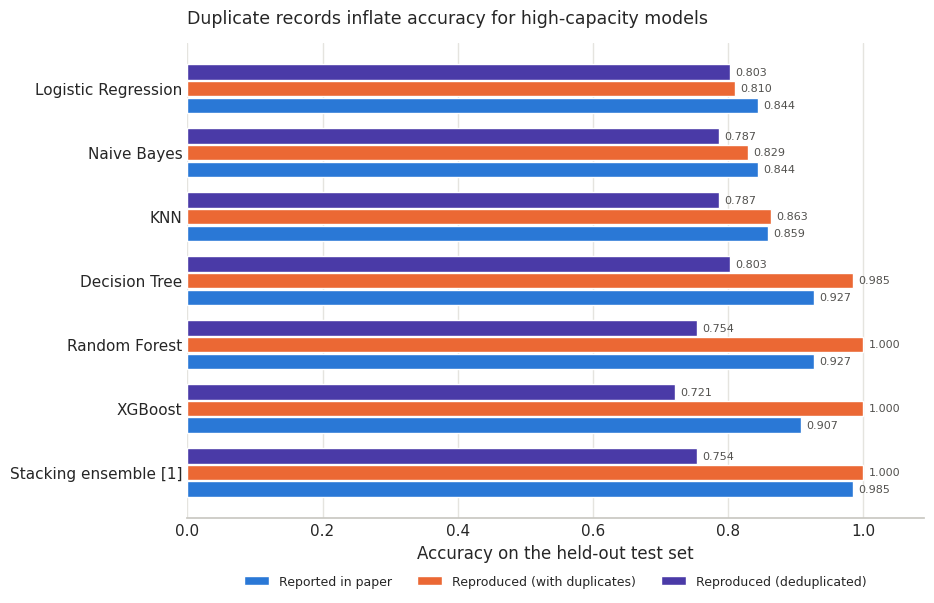

In [9]:
order = ["Logistic Regression","Naive Bayes","KNN","Decision Tree",
         "Random Forest","XGBoost","Stacking ensemble [1]"]

C = {"paper": "#2a78d6", "dupes": "#eb6834", "clean": "#4a3aa7"}
series = [("Reported in paper",            paper.loc[order, "Accuracy"].values, C["paper"]),
          ("Reproduced (with duplicates)", repro.loc[order, "Accuracy"].values, C["dupes"]),
          ("Reproduced (deduplicated)",    clean.loc[order, "Accuracy"].values, C["clean"])]

y, h = np.arange(len(order)), 0.26
fig, ax = plt.subplots(figsize=(9.5, 6.2))
for i, (label, vals, colour) in enumerate(series):
    pos = y + (1 - i) * h
    ax.barh(pos, vals, height=h * 0.92, color=colour, label=label, zorder=3)
    for p, v in zip(pos, vals):
        ax.text(v + 0.008, p, f"{v:.3f}", va="center", fontsize=8, color="#52514e")

ax.set_yticks(y); ax.set_yticklabels(order); ax.invert_yaxis()
ax.set_xlim(0, 1.09); ax.set_xlabel("Accuracy on the held-out test set")
ax.set_title("Duplicate records inflate accuracy for high-capacity models",
             pad=14, fontsize=12.5, loc="left")
ax.xaxis.grid(True, color="#e5e4df", zorder=0); ax.yaxis.grid(False); ax.set_axisbelow(True)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#c9c8c2"); ax.tick_params(length=0)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.17), ncol=3, frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig("fig_leakage.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

In [10]:
from scipy import stats

d = stability[stability["Data"] == "Deduplicated"].pivot(index="Seed", columns="Model", values="Accuracy")
a, b = d["Stacking ensemble [1]"], d["Logistic Regression"]

t_stat, p_t = stats.ttest_rel(a, b)
w_stat, p_w = stats.wilcoxon(a, b)
print(f"Stacking - Logistic Regression: mean difference {(a - b).mean():+.4f}")
print(f"Paired t-test:  t = {t_stat:.3f}, p = {p_t:.4f}")
print(f"Wilcoxon test:  p = {p_w:.4f}")

# How far is the paper's headline from our honest distribution?
mu, sd = a.mean(), a.std(ddof=1)
print(f"\nOur deduplicated stacking accuracy: {mu:.4f} ± {sd:.4f} over 30 splits")
print(f"Paper's reported 0.9853 sits {(0.9853 - mu) / sd:.1f} standard deviations above it")

Stacking - Logistic Regression: mean difference +0.0011
Paired t-test:  t = 0.311, p = 0.7577
Wilcoxon test:  p = 0.8181

Our deduplicated stacking accuracy: 0.8388 ± 0.0373 over 30 splits
Paper's reported 0.9853 sits 3.9 standard deviations above it


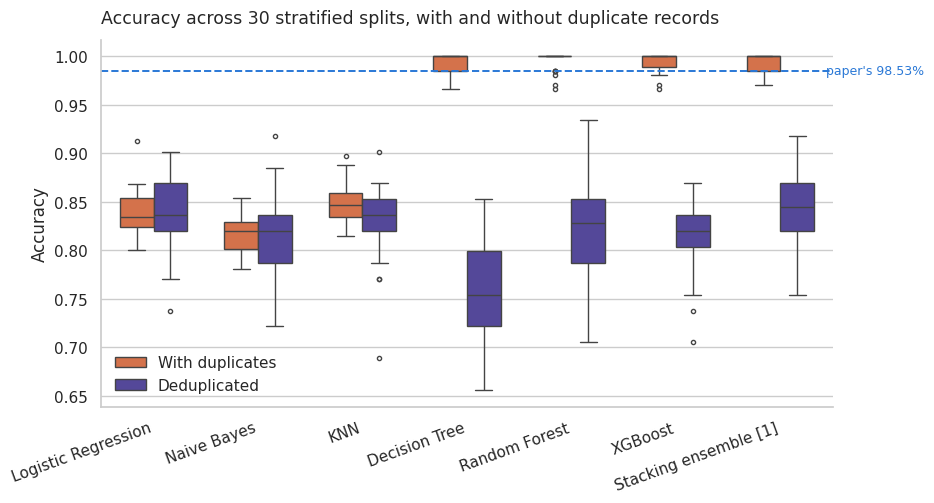

In [11]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
order2 = ["Logistic Regression","Naive Bayes","KNN","Decision Tree",
          "Random Forest","XGBoost","Stacking ensemble [1]"]
palette = {"With duplicates": "#eb6834", "Deduplicated": "#4a3aa7"}
sns.boxplot(data=stability, x="Model", y="Accuracy", hue="Data",
            order=order2, palette=palette, width=0.65, fliersize=3, ax=ax)
ax.axhline(0.9853, ls="--", lw=1.4, color="#2a78d6")
ax.text(6.4, 0.9853, " paper's 98.53%", va="center", fontsize=9, color="#2a78d6")
ax.set_title("Accuracy across 30 stratified splits, with and without duplicate records",
             loc="left", fontsize=12.5, pad=12)
ax.set_xlabel(""); ax.set_ylabel("Accuracy")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="", frameon=False, loc="lower left")
sns.despine()
fig.tight_layout()
fig.savefig("fig_stability.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

In [12]:
# Why does duplication inflate some models and not others?
# A leaked test record only helps a model that reproduces the labels of its own training records.
# So the gain from leakage is bounded by: fraction of test rows leaked x (train acc - test acc on clean data).
# Duplicates can also leak *inside* the stacking ensemble's own 5-fold CV, so its meta-learner weights are tracked.
records, meta = [], {"With duplicates": [], "Deduplicated": []}
for s in range(30):
    for tag, data in [("With duplicates", df), ("Deduplicated", df_clean)]:
        X, y = data.drop(columns="target"), data["target"]
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=s, stratify=y)
        seen = set(map(tuple, pd.concat([X_tr, y_tr], axis=1).values))
        leaked = np.array([tuple(r) in seen for r in pd.concat([X_te, y_te], axis=1).values])
        for name, m in build_models(s).items():
            m.fit(X_tr, y_tr)
            p = m.predict(X_te)
            records.append({"Data": tag, "Model": name, "Leaked": leaked.mean(),
                            "Train acc": accuracy_score(y_tr, m.predict(X_tr)),
                            "Test acc": accuracy_score(y_te, p),
                            "Acc on leaked rows": accuracy_score(y_te[leaked], p[leaked]) if leaked.any() else np.nan})
            if name == "Stacking ensemble [1]":
                meta[tag].append(m.final_estimator_.coef_[0])

R = pd.DataFrame(records)
dup = R[R["Data"] == "With duplicates"].groupby("Model").mean(numeric_only=True)
cln = R[R["Data"] == "Deduplicated"].groupby("Model").mean(numeric_only=True)
leak = pd.DataFrame({
    "Train acc (dedup)":   cln["Train acc"],
    "Test acc (dedup)":    cln["Test acc"],
    "Acc on leaked rows":  dup["Acc on leaked rows"],
    "Observed inflation":  dup["Test acc"] - cln["Test acc"],
    "Bound: f x gap":      dup["Leaked"] * (cln["Train acc"] - cln["Test acc"]),
}).loc[order].round(3) + 0.0   # "+ 0.0" avoids printing -0.000
print(f"Mean fraction of test rows leaked (f): {dup['Leaked'].mean():.3f}")
display(leak)

# Duplicates are spread almost evenly, so for logistic regression they act as a near-uniform re-weighting
copies = df.groupby(list(df.columns)).size().value_counts().sort_index()
print("\nCopies per unique record:", {int(k): int(v) for k, v in copies.items()})
Xd, Xc_ = df.drop(columns="target"), df_clean.drop(columns="target")
lr_dup = build_models()["Logistic Regression"].fit(Xd, df["target"])
lr_cln = build_models()["Logistic Regression"].fit(Xc_, df_clean["target"])
w_dup = lr_dup.named_steps["m"].coef_[0] / lr_dup.named_steps["sc"].scale_
w_cln = lr_cln.named_steps["m"].coef_[0] / lr_cln.named_steps["sc"].scale_
cos = w_dup @ w_cln / (np.linalg.norm(w_dup) * np.linalg.norm(w_cln))
agree = (lr_dup.predict(Xc_) == lr_cln.predict(Xc_)).mean()
print(f"Logistic regression fitted with vs without duplicates: coefficient cosine similarity {cos:.3f}, "
      f"identical prediction for {agree:.1%} of the 302 unique patients")

meta_w = pd.DataFrame({k: np.mean(v, axis=0) for k, v in meta.items()},
                      index=["LR", "DT", "RF", "XGB", "NB", "KNN"]).T.round(2)
print("\nStacking meta-learner weight on each base model (mean over 30 splits):")
display(meta_w)

Mean fraction of test rows leaked (f): 0.973


,Train acc (dedup),Test acc (dedup),Acc on leaked rows,Observed inflation,Bound: f x gap
Model,,,,,
Logistic Regression,0.850,0.838,0.838,0.000,0.012
Naive Bayes,0.844,0.815,0.819,0.001,0.028
KNN,0.872,0.830,0.850,0.018,0.042
Decision Tree,1.000,0.760,1.000,0.232,0.233
Random Forest,1.000,0.819,1.000,0.176,0.176
XGBoost,1.000,0.813,1.000,0.182,0.182
Stacking ensemble [1],0.931,0.839,1.000,0.156,0.090



Copies per unique record: {3: 187, 4: 114, 8: 1}
Logistic regression fitted with vs without duplicates: coefficient cosine similarity 0.996, identical prediction for 97.4% of the 302 unique patients

Stacking meta-learner weight on each base model (mean over 30 splits):


,LR,DT,RF,XGB,NB,KNN
With duplicates,0.17,2.20,3.41,2.54,0.48,1.02
Deduplicated,1.12,0.18,1.29,0.56,1.10,1.03


In [13]:
import urllib.request, zipfile, io

URL = "https://archive.ics.uci.edu/static/public/45/heart+disease.zip"
z = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(URL).read()))
print(z.namelist())

cols = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach",
        "exang","oldpeak","slope","ca","thal","num"]
sources = {"Cleveland":     "processed.cleveland.data",
           "Hungary":       "processed.hungarian.data",
           "Switzerland":   "processed.switzerland.data",
           "Long Beach VA": "processed.va.data"}

frames = {}
for name, fname in sources.items():
    d = pd.read_csv(z.open(fname), names=cols, na_values="?")
    d["target"] = (d["num"] > 0).astype(int)     # 0 = no disease, 1-4 = disease
    frames[name] = d.drop(columns="num").assign(source=name)

ext = pd.concat(frames.values(), ignore_index=True)

print("\nRecords and positive rate per database:")
print(ext.groupby("source").agg(n=("target","size"),
                                positive_rate=("target","mean")).round(3))
print("\nMissing values (%) per database:")
print((ext.groupby("source").apply(lambda g: g.isna().mean() * 100, include_groups=False)
          .round(1)))

['Index', 'WARNING', 'ask-detrano', 'bak', 'cleve.mod', 'cleveland.data', 'costs/', 'costs/Index', 'costs/heart-disease.README', 'costs/heart-disease.cost', 'costs/heart-disease.delay', 'costs/heart-disease.expense', 'costs/heart-disease.group', 'heart-disease.names', 'hungarian.data', 'long-beach-va.data', 'new.data', 'processed.cleveland.data', 'processed.hungarian.data', 'processed.switzerland.data', 'processed.va.data', 'reprocessed.hungarian.data', 'switzerland.data']

Records and positive rate per database:
                 n  positive_rate
source                           
Cleveland      303          0.459
Hungary        294          0.361
Long Beach VA  200          0.745
Switzerland    123          0.935

Missing values (%) per database:
               age  sex   cp  trestbps  chol   fbs  restecg  thalach  exang  \
source                                                                        
Cleveland      0.0  0.0  0.0       0.0   0.0   0.0      0.0      0.0    0.0   
Hungar

In [14]:
FEATURES_ALL = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach",
                "exang","oldpeak","slope","ca","thal"]

# Switzerland records cholesterol as 0 for nearly every patient: a coded missing value, not a measurement
print("Rows with chol == 0 per site:")
print(ext[ext["chol"] == 0].groupby("source").size())
ext.loc[ext["chol"] == 0, "chol"] = np.nan

availability = (100 - ext.groupby("source")[FEATURES_ALL]
                        .apply(lambda g: g.isna().mean() * 100, include_groups=False)).round(1)
print("\nFeature availability (% present) per site:")
display(availability)

# Keep only features recorded in at least half of every external site
external_sites = ["Hungary", "Switzerland", "Long Beach VA"]
TRANSFERABLE = [c for c in FEATURES_ALL
                if (availability.loc[external_sites, c] >= 50).all()]
print("\nTransferable feature set:", TRANSFERABLE)
print("Excluded (site-specific):", [c for c in FEATURES_ALL if c not in TRANSFERABLE])

Rows with chol == 0 per site:
source
Long Beach VA     49
Switzerland      123
dtype: int64

Feature availability (% present) per site:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
source,,,,,,,,,,,,,
Cleveland,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,98.7,99.3
Hungary,100.0,100.0,100.0,99.7,92.2,97.3,99.7,99.7,99.7,100.0,35.4,1.0,9.5
Long Beach VA,100.0,100.0,100.0,72.0,72.0,96.5,100.0,73.5,73.5,72.0,49.0,1.0,17.0
Switzerland,100.0,100.0,100.0,98.4,0.0,39.0,99.2,99.2,99.2,95.1,86.2,4.1,57.7



Transferable feature set: ['age', 'sex', 'cp', 'trestbps', 'restecg', 'thalach', 'exang', 'oldpeak']
Excluded (site-specific): ['chol', 'fbs', 'slope', 'ca', 'thal']


In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import fbeta_score

SEED = 42
cle = frames["Cleveland"].drop_duplicates().reset_index(drop=True)
Xc, yc = cle[TRANSFERABLE], cle["target"]
print(f"Cleveland training set: {len(cle)} unique patients, {yc.mean():.1%} positive")

def stack_clf(seed=SEED):
    return StackingClassifier(
        estimators=[("lr",  LogisticRegression(max_iter=1000, random_state=seed)),
                    ("dt",  DecisionTreeClassifier(random_state=seed)),
                    ("rf",  RandomForestClassifier(n_estimators=100, random_state=seed)),
                    ("xgb", XGBClassifier(eval_metric="logloss", random_state=seed)),
                    ("nb",  GaussianNB()),
                    ("knn", KNeighborsClassifier(5))],
        final_estimator=LogisticRegression(max_iter=1000, random_state=seed), cv=5, n_jobs=-1)

def prep(steps):
    """Imputation and scaling are fitted inside CV folds, never on the full dataset."""
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc",  StandardScaler())] + steps)

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

# Config C - the paper's ensemble, restricted to transferable features, default 0.5 threshold
config_C = prep([("clf", stack_clf())]).fit(Xc, yc)

# Config D - proposed: mutual-information feature selection (k tuned) + probability calibration
inner = prep([("sel", SelectKBest(mutual_info_classif)),
              ("clf", CalibratedClassifierCV(stack_clf(), method="sigmoid", cv=5))])
grid = GridSearchCV(inner, {"sel__k": [4, 6, 8]}, scoring="roc_auc", cv=cv, n_jobs=-1).fit(Xc, yc)
config_D = grid.best_estimator_
print("Selected k:", grid.best_params_["sel__k"])

# Decision threshold tuned on out-of-fold predictions for F2 (recall weighted 2x),
# subject to precision >= 0.60 so the trivial "everyone is positive" solution is excluded
oof = cross_val_predict(config_D, Xc, yc, cv=cv, method="predict_proba")[:, 1]
cands = []
for t in np.linspace(0.05, 0.95, 91):
    pred = (oof >= t).astype(int)
    p = precision_score(yc, pred, zero_division=0)
    if p >= 0.60:
        cands.append((fbeta_score(yc, pred, beta=2, zero_division=0), t, p))
F2, TH, PREC = max(cands)
print(f"Tuned threshold: {TH:.2f}  (out-of-fold F2 = {F2:.3f}, precision = {PREC:.3f})")

def scores(config, site, y, proba, th):
    pred = (proba >= th).astype(int)
    return {"Config": config, "Test site": site,
            "Accuracy":  accuracy_score(y, pred),
            "Recall":    recall_score(y, pred, zero_division=0),
            "Precision": precision_score(y, pred, zero_division=0),
            "F1":        f1_score(y, pred, zero_division=0),
            "F2":        fbeta_score(y, pred, beta=2, zero_division=0),
            "AUC":       roc_auc_score(y, proba),
            "MCC":       matthews_corrcoef(y, pred)}

rows = []
for site in ["Hungary", "Switzerland", "Long Beach VA"]:
    d = frames[site]
    Xs, ys = d[TRANSFERABLE], d["target"]
    rows.append(scores("C: paper pipeline", site, ys, config_C.predict_proba(Xs)[:, 1], 0.50))
    rows.append(scores("D: proposed",       site, ys, config_D.predict_proba(Xs)[:, 1], TH))

external = pd.DataFrame(rows).set_index(["Test site", "Config"]).round(3)
external

Cleveland training set: 303 unique patients, 45.9% positive
Selected k: 8
Tuned threshold: 0.21  (out-of-fold F2 = 0.848, precision = 0.629)


Accuracy  Recall  Precision     F1     F2  \
Test site     Config                                                         
Hungary       C: paper pipeline     0.830   0.736      0.780  0.757  0.744   
              D: proposed           0.731   0.896      0.583  0.706  0.809   
Switzerland   C: paper pipeline     0.724   0.739      0.955  0.833  0.774   
              D: proposed           0.919   0.957      0.957  0.957  0.957   
Long Beach VA C: paper pipeline     0.720   0.805      0.816  0.811  0.808   
              D: proposed           0.760   0.973      0.767  0.858  0.924   

                                   AUC    MCC  
Test site     Config                           
Hungary       C: paper pipeline  0.879  0.627  
              D: proposed        0.884  0.516  
Switzerland   C: paper pipeline  0.775  0.132  
              D: proposed        0.760  0.332  
Long Beach VA C: paper pipeline  0.727  0.273  
              D: proposed        0.732  0.211

In [16]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import make_scorer

# The full metric set promised in Section 7. scikit-learn returns the Brier score
# negated (its convention is "higher is better"), so the sign is flipped on output.
SCORING = {
    "Accuracy":  "accuracy",
    "Precision": "precision",
    "Recall":    "recall",
    "F1":        "f1",
    "F2":        make_scorer(fbeta_score, beta=2),
    "AUC":       "roc_auc",
    "MCC":       make_scorer(matthews_corrcoef),
    "Brier":     "neg_brier_score",
}

rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=6, random_state=SEED)
internal = cross_validate(config_D, Xc, yc, cv=rcv, n_jobs=-1, scoring=SCORING)

print("Cleveland internal (30 folds: 5-fold x 6 repeats), proposed pipeline")
print("Label-based metrics use the default 0.5 threshold; AUC and Brier are threshold-free.\n")
for m in SCORING:
    v = internal[f"test_{m}"]
    if m == "Brier":
        v = -v                      # undo scikit-learn's sign convention
    print(f"  {m:10s} {v.mean():.3f} ± {v.std():.3f}")

print(f"\nGeneralisation gap (AUC): Cleveland {internal['test_AUC'].mean():.3f}"
      f" vs external mean {external.xs('D: proposed', level='Config')['AUC'].mean():.3f}")

Cleveland internal (30 folds: 5-fold x 6 repeats), proposed pipeline
Label-based metrics use the default 0.5 threshold; AUC and Brier are threshold-free.

  Accuracy   0.807 ± 0.047
  Precision  0.828 ± 0.077
  Recall     0.739 ± 0.066
  F1         0.778 ± 0.054
  F2         0.753 ± 0.059
  AUC        0.876 ± 0.037
  MCC        0.614 ± 0.097
  Brier      0.145 ± 0.023

Generalisation gap (AUC): Cleveland 0.876 vs external mean 0.792


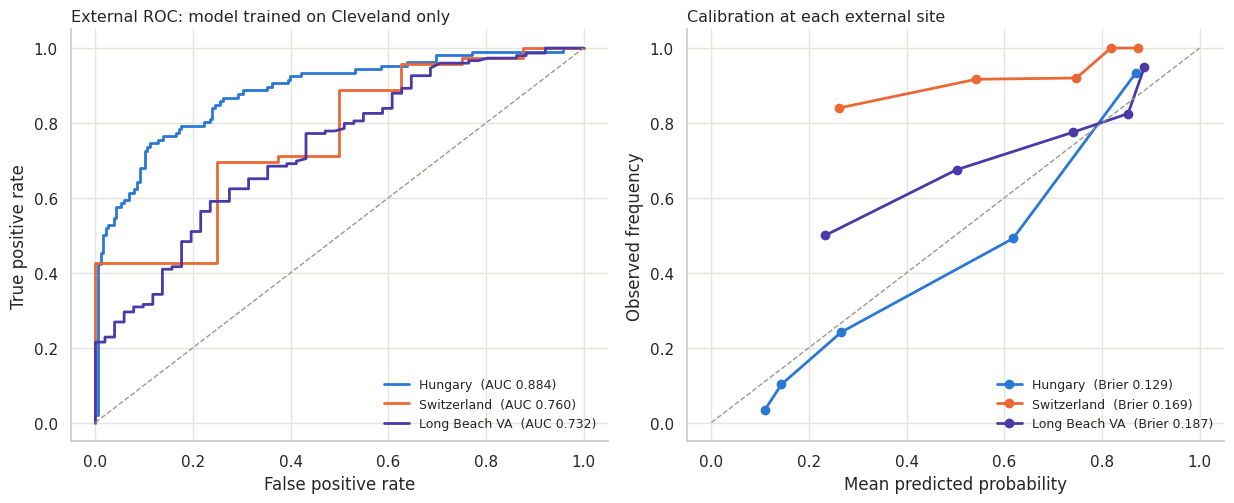

In [17]:
from sklearn.metrics import roc_curve, brier_score_loss
from sklearn.calibration import calibration_curve

C3 = {"Hungary": "#2a78d6", "Switzerland": "#eb6834", "Long Beach VA": "#4a3aa7"}
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))

for site, colour in C3.items():
    d = frames[site]
    ys, p = d["target"], config_D.predict_proba(d[TRANSFERABLE])[:, 1]
    fpr, tpr, _ = roc_curve(ys, p)
    axes[0].plot(fpr, tpr, color=colour, lw=2, label=f"{site}  (AUC {roc_auc_score(ys, p):.3f})")
    prob_true, prob_pred = calibration_curve(ys, p, n_bins=5, strategy="quantile")
    axes[1].plot(prob_pred, prob_true, "o-", color=colour, lw=2, ms=6,
                 label=f"{site}  (Brier {brier_score_loss(ys, p):.3f})")

axes[0].plot([0, 1], [0, 1], "--", color="#9a9993", lw=1)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("External ROC: model trained on Cleveland only", loc="left", fontsize=11.5)

axes[1].plot([0, 1], [0, 1], "--", color="#9a9993", lw=1)
axes[1].set_xlabel("Mean predicted probability"); axes[1].set_ylabel("Observed frequency")
axes[1].set_title("Calibration at each external site", loc="left", fontsize=11.5)

for ax in axes:
    ax.legend(frameon=False, fontsize=9, loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(color="#e5e4df"); ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig("fig_external.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

In [18]:
# The redistributed file and the original UCI Cleveland database are not the same cohort.
print("Kaggle redistribution:", len(df), "rows ->",
      df.drop_duplicates().shape[0], "unique")
print("UCI Cleveland:        ", len(frames["Cleveland"]), "rows ->",
      frames["Cleveland"].drop_duplicates().shape[0], "unique")

Kaggle redistribution: 1025 rows -> 302 unique
UCI Cleveland:         303 rows -> 303 unique
